# Enviroment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = '/content/drive/MyDrive/DP'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/SARIMA'

# Processed Data

In [4]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

# Model Definition - SARIMA

In [8]:
def run_sarima_prediction(df, dataset_name, dataset_code, dataset_number, test_days=90, order=(1,1,1), seasonal_order=(1,1,1,7)):
    """
    Train SARIMA on a single dataset and return metrics + predictions.

    Parameters:
        df: processed DataFrame with 'date' and 'total_tonnes' columns
        dataset_name: display name for plots
        dataset_code: short code for file naming
        dataset_number: number code for plot naming
        test_days: number of days to hold out for testing
        order: SARIMA (p,d,q) parameters
        seasonal_order: SARIMA (P,D,Q,s) seasonal parameters
    """
    print(f"\n{'='*100}")
    print(f"SARIMA PREDICTION — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)

    # test / train split
    train = df.iloc[:-test_days]
    test = df.iloc[-test_days:]

    print(f"Train: {len(train)} days ({train['date'].min().date()} → {train['date'].max().date()})")
    print(f"Test:  {len(test)} days ({test['date'].min().date()} → {test['date'].max().date()})")

    # model fit
    print(f"\nFitting SARIMA{order}x{seasonal_order}...")
    try:
        model = SARIMAX(
            train['total_tonnes'],
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False, maxiter=200)
        print(f"Model fitted. AIC: {fitted.aic:.2f}")

    except Exception as e:
        print(f"ERROR fitting SARIMA: {e}")
        print("Trying simpler model SARIMA(1,1,0)(1,1,0,7)...")
        model = SARIMAX(
            train['total_tonnes'],
            order=(1,1,0),
            seasonal_order=(1,1,0,7),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        fitted = model.fit(disp=False, maxiter=200)
        print(f"Fallback model fitted. AIC: {fitted.aic:.2f}")

    # forecast - no negatives
    forecast = fitted.forecast(steps=test_days)
    forecast = forecast.clip(lower=0)

    # metrics
    y_true = test['total_tonnes'].values
    y_pred = forecast.values

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE calc
    nonzero_mask = y_true > 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    else:
        mape = float('nan')

    print(f"\n--- RESULTS ---")
    print(f"MAE:  {mae:.2f} tonnes")
    print(f"RMSE: {rmse:.2f} tonnes")
    print(f"MAPE: {mape:.2f}%")


    # --- Plot 1X1: Actual vs Predicted (test period) - SARIMA ---
    fig, ax = plt.subplots(figsize=(16, 6))

    # last 30 days
    context = train.iloc[-30:]
    ax.plot(context['date'], context['total_tonnes'], color='steelblue',
            linewidth=1, label='Training Data (last 30 days)')

    ax.plot(test['date'], y_true, color='steelblue',
            linewidth=1.5, label='Actual (Test)')

    ax.plot(test['date'], y_pred, color='red',
            linewidth=1.5, linestyle='--', label='SARIMA Forecast')

    ax.axvline(x=test['date'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

    ax.set_title(f'SARIMA Forecast vs Actual — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)

    # metrics
    ax.text(0.02, 0.95,
            f'MAE: {mae:.2f}t\nRMSE: {rmse:.2f}t\nMAPE: {mape:.1f}%',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'1{dataset_number}1_sarima_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 1X2: Zoom on firts 30 days of test - SARIMA ---
    fig, ax = plt.subplots(figsize=(14, 5))

    zoom_days = min(30, test_days)
    ax.plot(test['date'].iloc[:zoom_days], y_true[:zoom_days],
            color='steelblue', linewidth=2, marker='o', markersize=3, label='Actual')

    ax.plot(test['date'].iloc[:zoom_days], y_pred[:zoom_days],
            color='red', linewidth=2, marker='s', markersize=3, linestyle='--', label='SARIMA')

    ax.set_title(f'SARIMA Forecast (First {zoom_days} Days) — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'1{dataset_number}2_sarima_forecast_zoom_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'dataset': dataset_name,
        'model': 'SARIMA',
        'mae': round(mae, 2),
        'rmse': round(rmse, 2),
        'mape': round(mape, 2),
        'test_days': test_days,
        'aic': round(fitted.aic, 2)
    }

# Model Prediction - SARIMA


SARIMA PREDICTION — Boralesgamuwa UC (Sri Lanka)
Train: 2287 days (2012-01-31 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)

Fitting SARIMA(1, 1, 1)x(1, 1, 1, 7)...
Model fitted. AIC: 16185.68

--- RESULTS ---
MAE:  7.27 tonnes
RMSE: 9.20 tonnes
MAPE: 45.11%


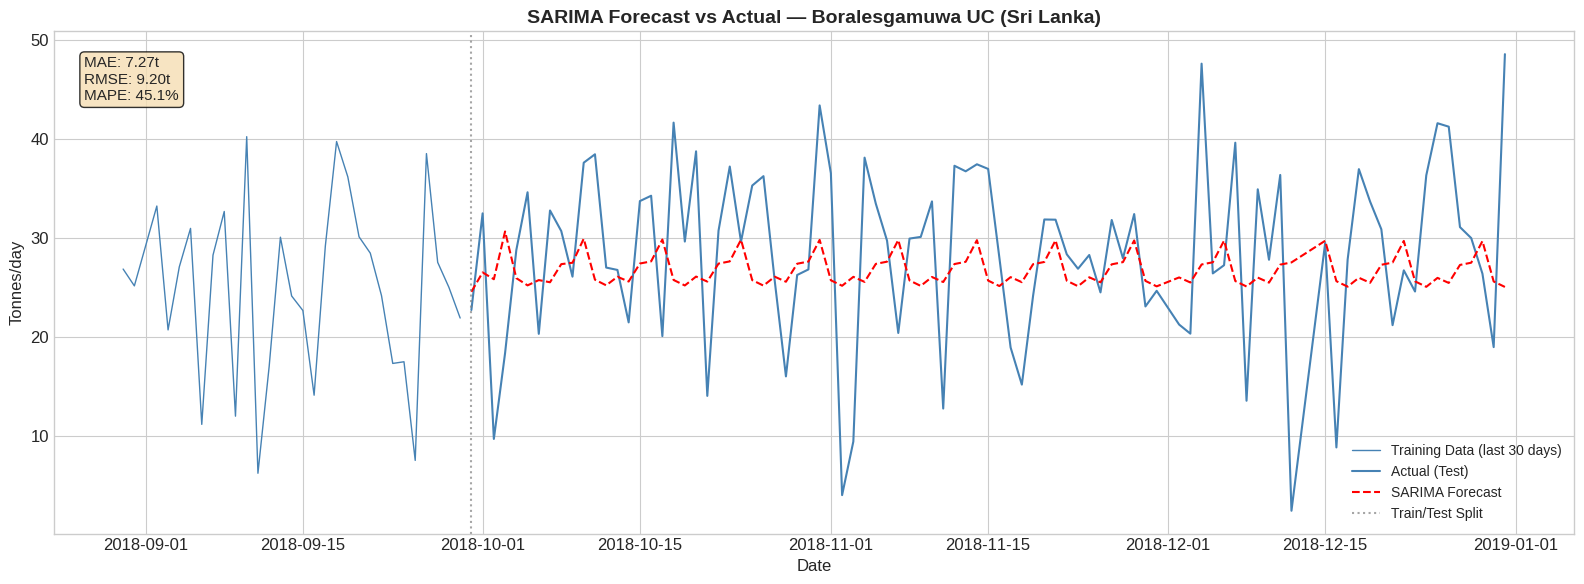

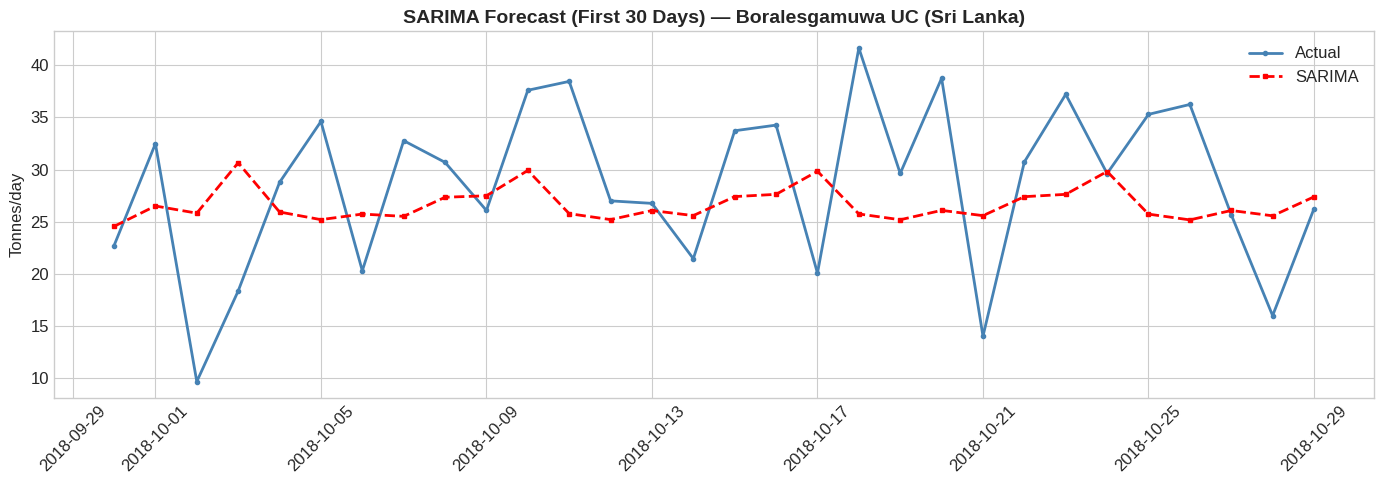


SARIMA PREDICTION — Dehiwala MC (Sri Lanka)
Train: 2003 days (2012-01-31 → 2018-09-25)
Test:  90 days (2018-09-26 → 2018-12-31)

Fitting SARIMA(1, 1, 1)x(1, 1, 1, 7)...
Model fitted. AIC: 20371.00

--- RESULTS ---
MAE:  40.75 tonnes
RMSE: 46.88 tonnes
MAPE: 55.17%


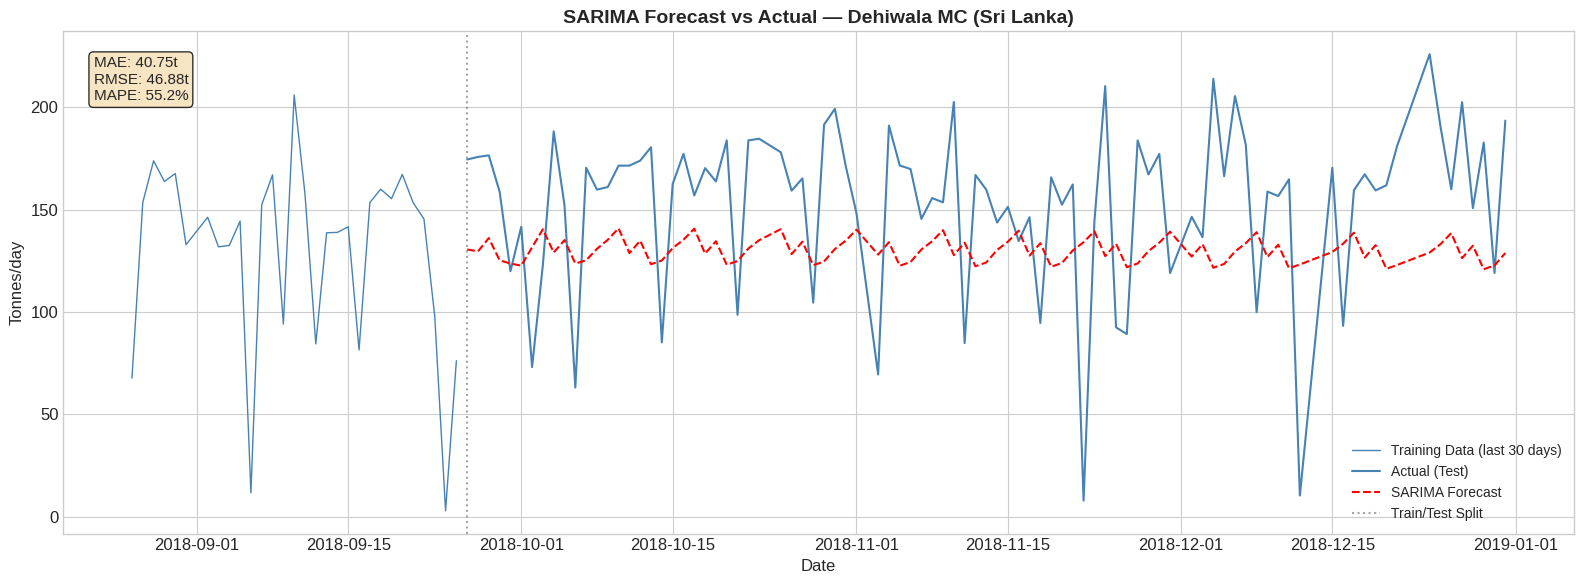

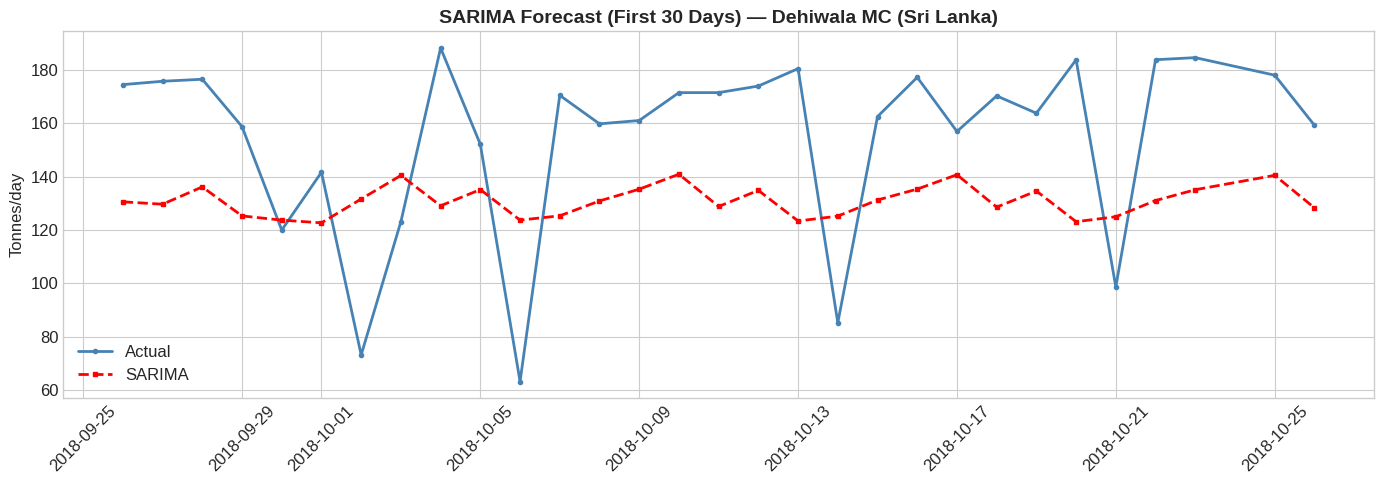


SARIMA PREDICTION — Homagama PS (Sri Lanka)
Train: 1944 days (2012-02-02 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)

Fitting SARIMA(1, 1, 1)x(1, 1, 1, 7)...
Model fitted. AIC: 15592.34

--- RESULTS ---
MAE:  11.16 tonnes
RMSE: 14.93 tonnes
MAPE: 36.65%


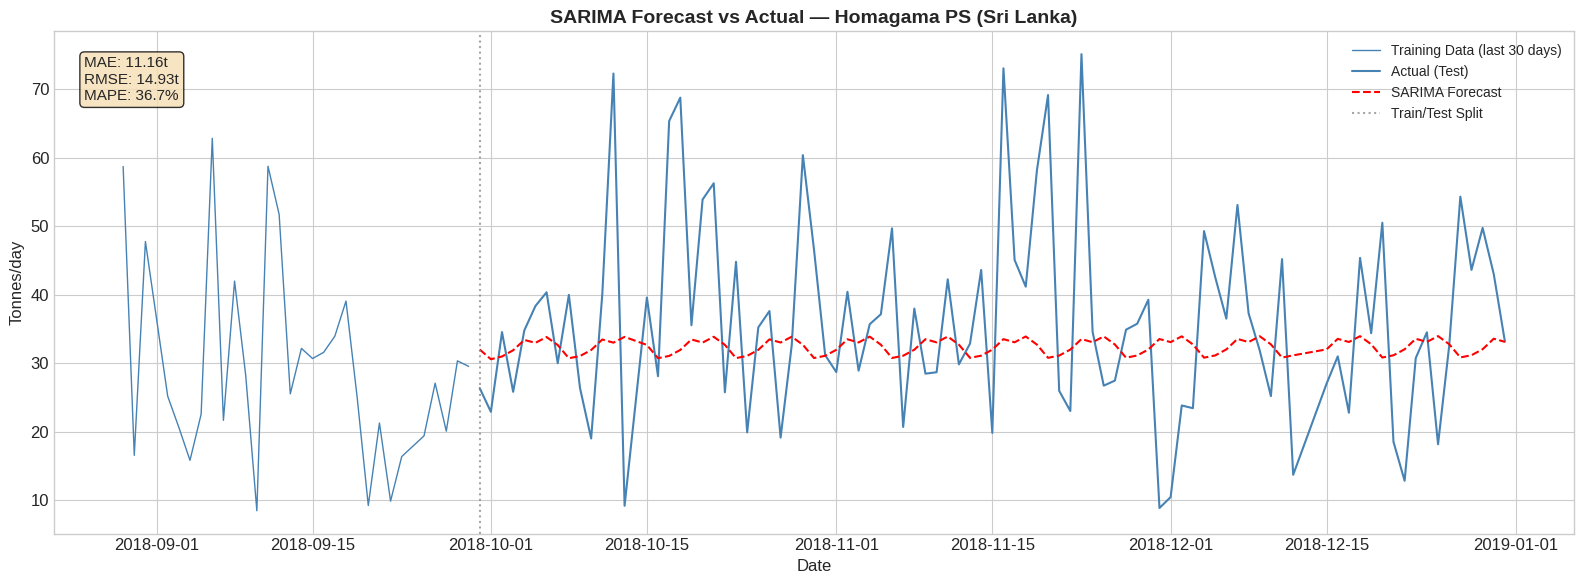

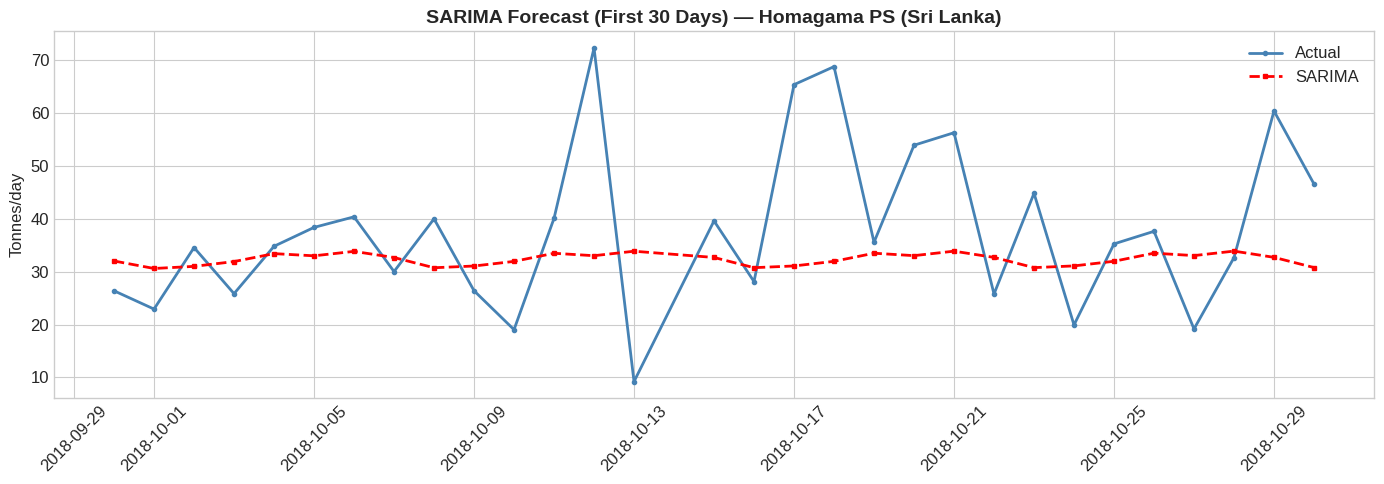


SARIMA PREDICTION — Moratuwa MC (Sri Lanka)
Train: 1176 days (2015-01-31 → 2018-09-08)
Test:  90 days (2018-09-09 → 2018-12-11)

Fitting SARIMA(1, 1, 1)x(1, 1, 1, 7)...
Model fitted. AIC: 10779.96

--- RESULTS ---
MAE:  19.39 tonnes
RMSE: 25.26 tonnes
MAPE: 33.65%


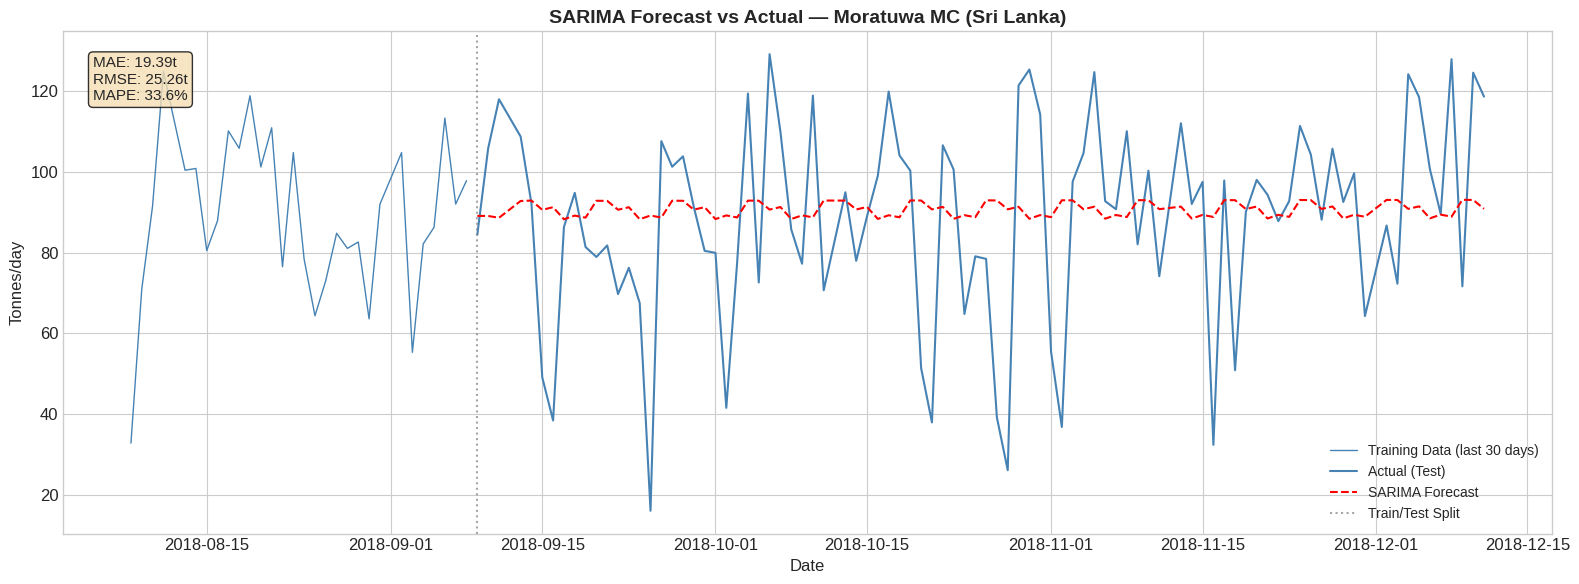

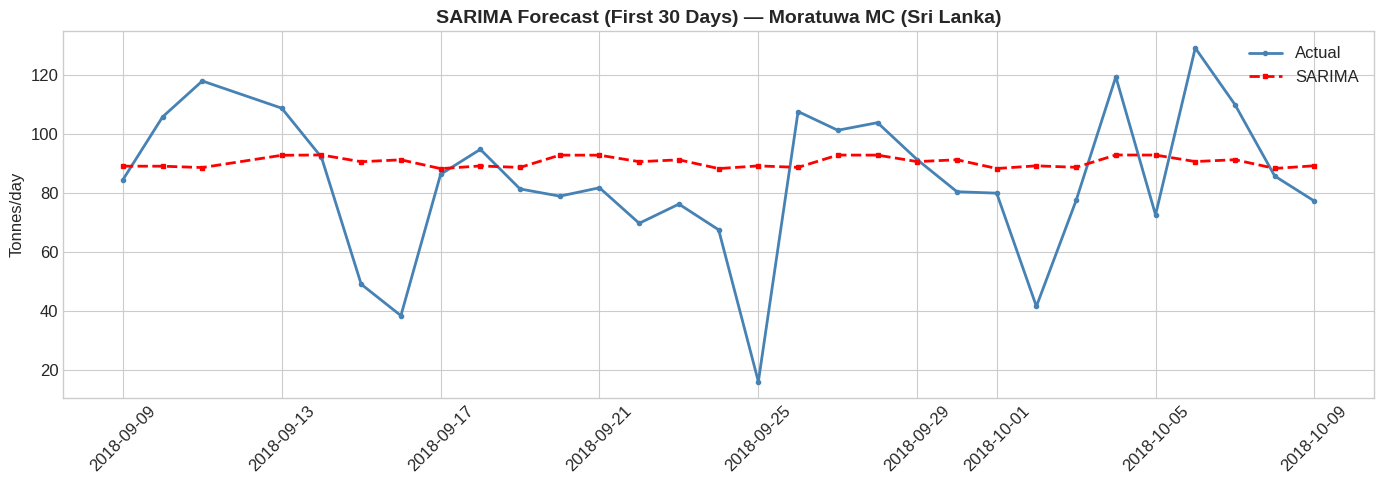


SARIMA PREDICTION — Austin TX (USA)
Train: 5208 days (2005-02-01 → 2020-09-18)
Test:  90 days (2020-09-19 → 2020-12-31)

Fitting SARIMA(1, 1, 1)x(1, 1, 1, 7)...
Model fitted. AIC: 82898.32

--- RESULTS ---
MAE:  638.50 tonnes
RMSE: 808.34 tonnes
MAPE: 1419.98%


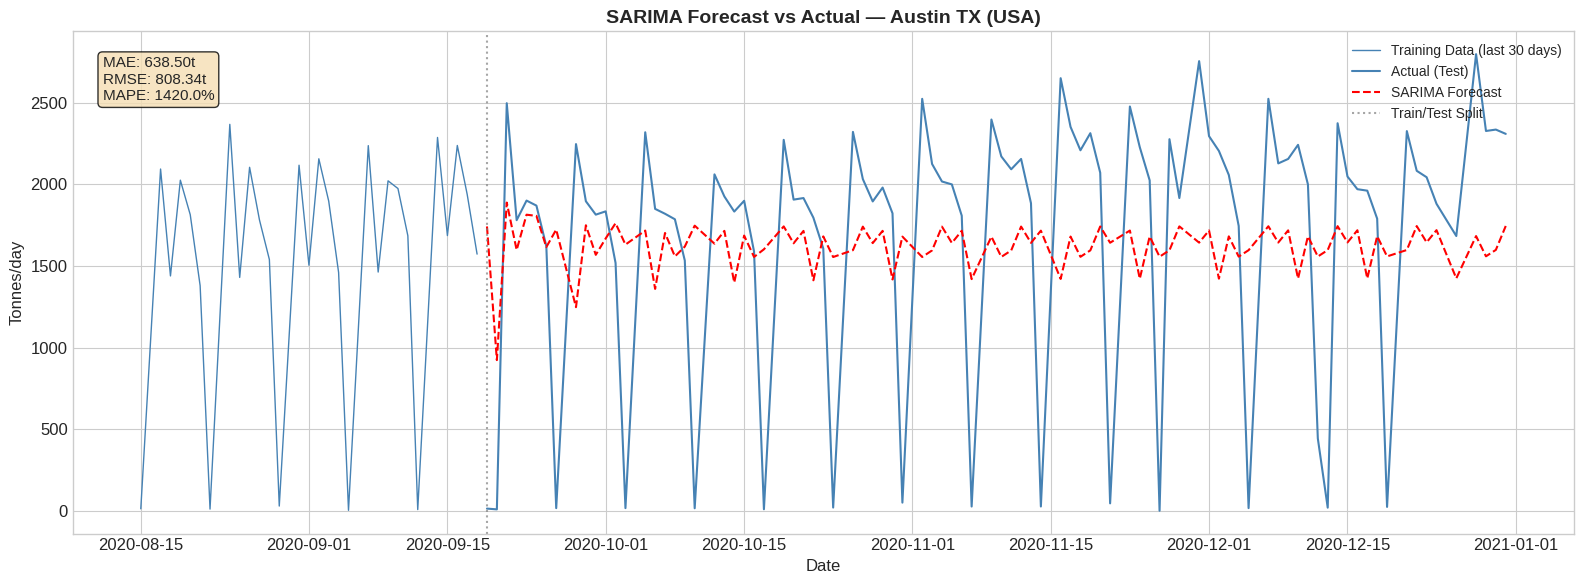

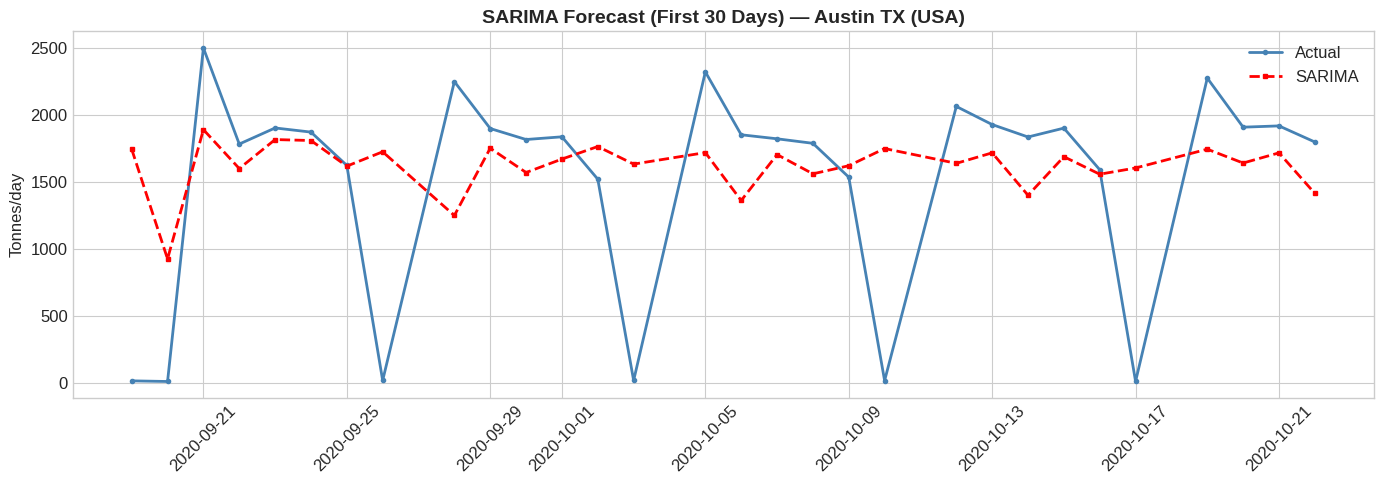


SARIMA PREDICTION — Ballarat (Australia)
Train: 3570 days (2001-02-01 → 2014-09-17)
Test:  90 days (2014-09-18 → 2014-12-31)

Fitting SARIMA(1, 1, 1)x(1, 1, 1, 7)...
Model fitted. AIC: 27732.93

--- RESULTS ---
MAE:  24.91 tonnes
RMSE: 33.20 tonnes
MAPE: 130.72%


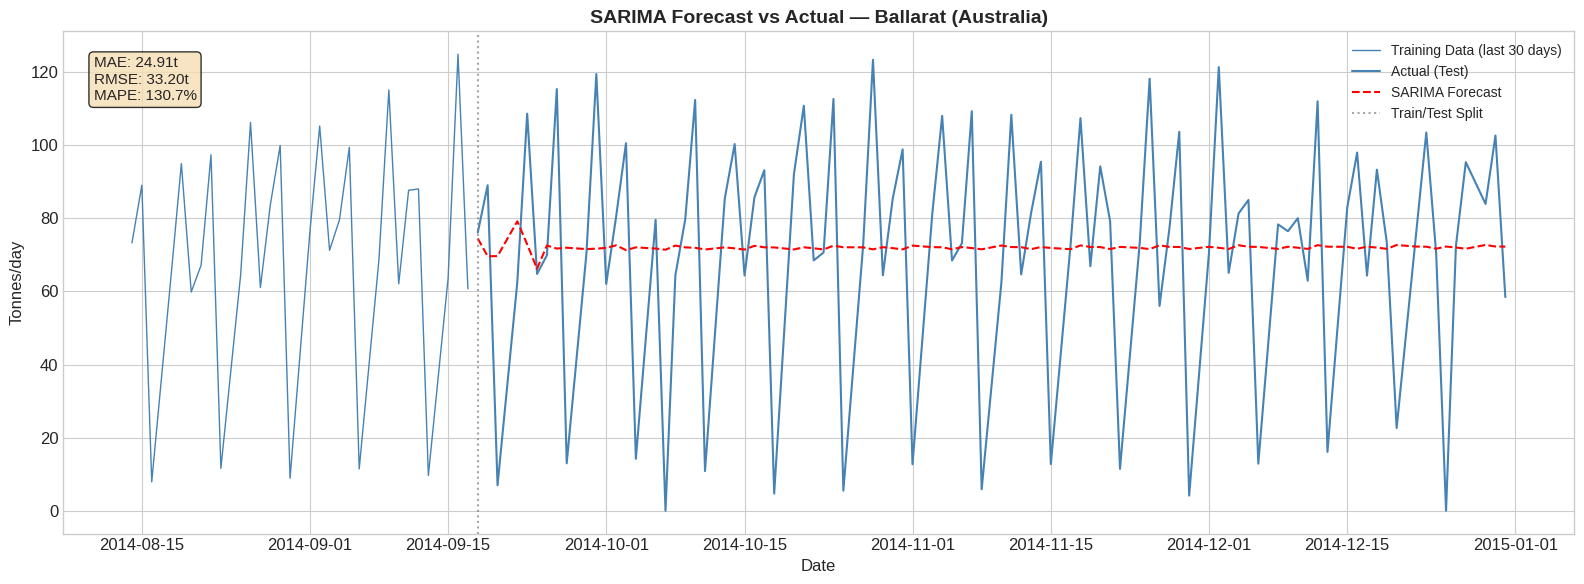

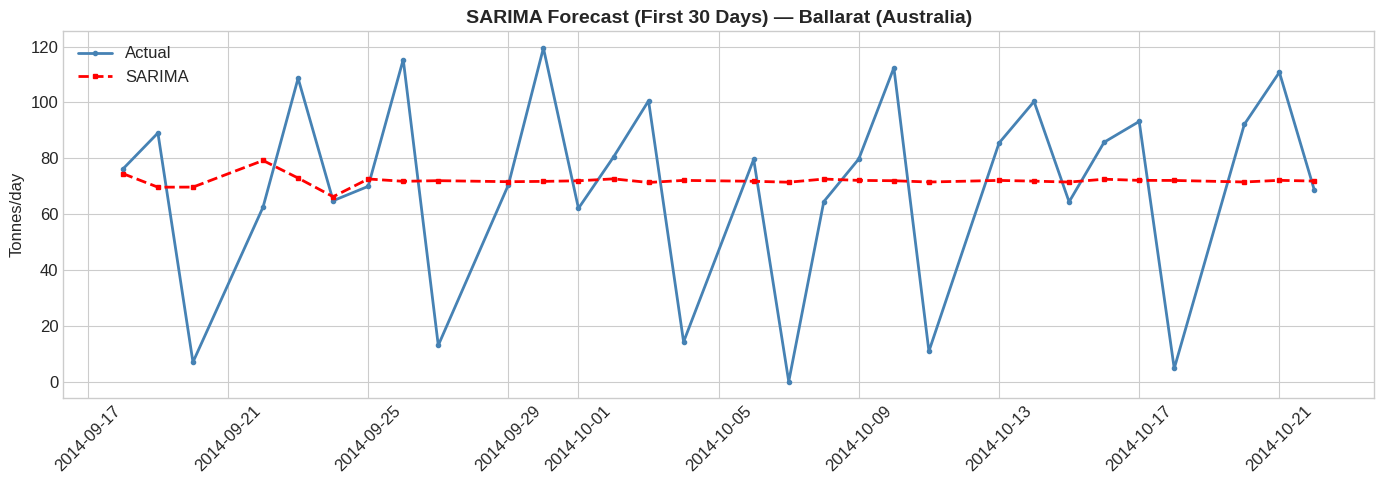

In [9]:
all_results = []

for name, config in DATASETS.items():
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_sarima_prediction(
            df = df,
            dataset_name = config['label'],
            dataset_code = config['code'],
            dataset_number = config['number'],
            test_days = 90,
            order = (1,1,1),
            seasonal_order = (1,1,1,7)
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

# Prediction Summary

In [10]:
print("\n" + "=" * 100)
print("SARIMA RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

results_df = pd.DataFrame(all_results)

print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'MAPE (%)':>9s} | {'AIC':>10s}")
print("-" * 75)
for _, row in results_df.iterrows():
    print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['mape']:>8.2f}% | {row['aic']:>10.2f}")

# avg metrics
print("-" * 75)
print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['mape'].mean():>8.2f}% |")

# save results
results_df.to_csv(os.path.join(RES_DIR, 'sarima_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/sarima_results.csv")


SARIMA RESULTS SUMMARY — ALL DATASETS

Dataset                        |  MAE (t) |  RMSE (t) |  MAPE (%) |        AIC
---------------------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     7.27 |      9.20 |    45.11% |   16185.68
Dehiwala MC (Sri Lanka)        |    40.75 |     46.88 |    55.17% |   20371.00
Homagama PS (Sri Lanka)        |    11.16 |     14.93 |    36.65% |   15592.34
Moratuwa MC (Sri Lanka)        |    19.39 |     25.26 |    33.65% |   10779.96
Austin TX (USA)                |   638.50 |    808.34 |  1419.98% |   82898.32
Ballarat (Australia)           |    24.91 |     33.20 |   130.72% |   27732.93
---------------------------------------------------------------------------
AVERAGE                        |   123.66 |    156.30 |   286.88% |

Results saved to: /content/drive/MyDrive/DP/05_prediction_results/sarima_results.csv


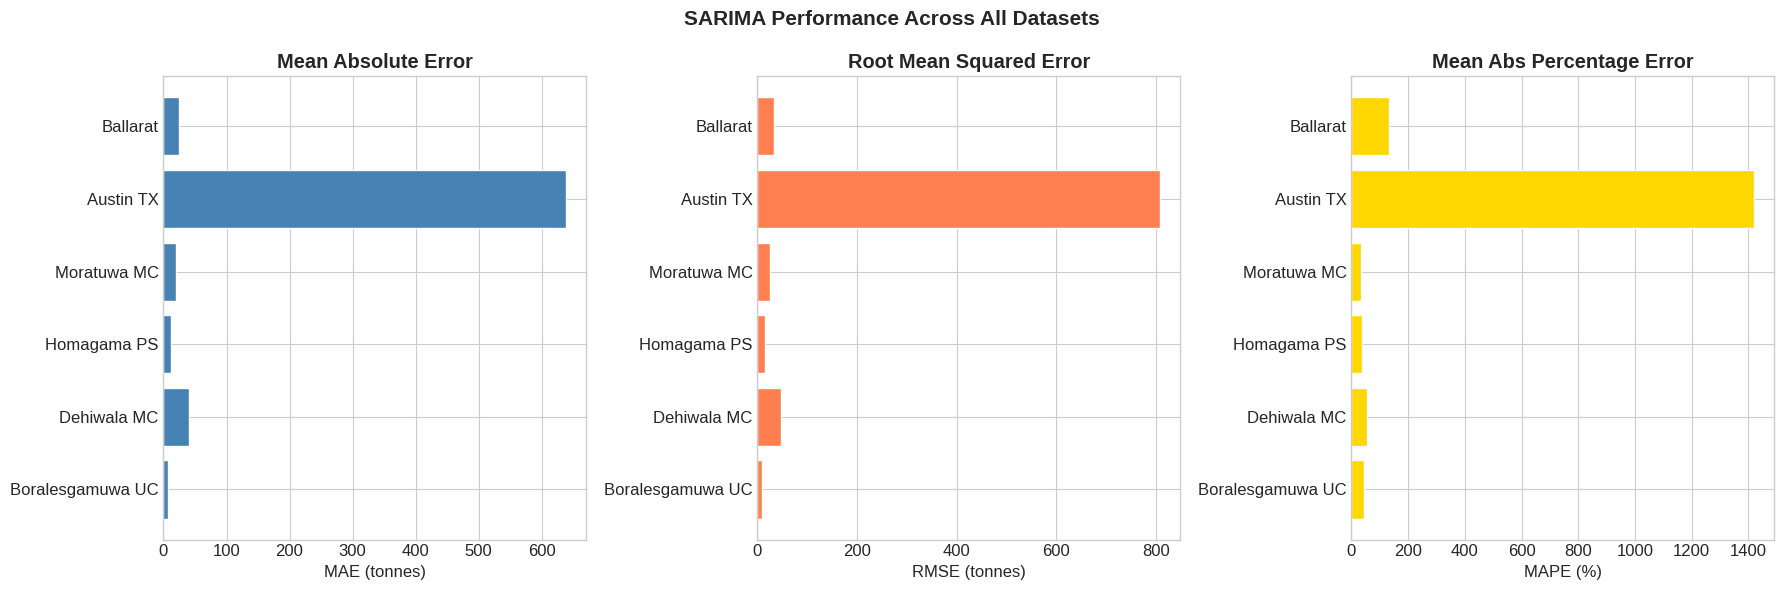

In [11]:
# --- Plot 101: SARIMA Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

# MAE comparison
axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

# RMSE comparison
axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

# MAPE comparison
axes[2].barh(short_names, results_df['mape'], color='gold', edgecolor='white')
axes[2].set_xlabel('MAPE (%)')
axes[2].set_title('Mean Abs Percentage Error', fontweight='bold')

plt.suptitle('SARIMA Performance Across All Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '101_sarima_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()